In [1]:
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

In [3]:
X_fantoma = np.array([
[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0],
[0.0, 0.0, 0.8, 0.3, 0.3, 0.3, 0.0, 0.0],
[0.0, 0.8, 0.8, 0.8, 0.3, 0.3, 0.3, 0.0],
[0.0, 0.3, 0.8, 0.3, 0.3, 0.3, 0.3, 0.0],
[0.0, 0.3, 0.3, 0.3, 0.3, 0.5, 0.3, 0.0],
[0.0, 0.3, 0.3, 0.3, 0.5, 0.5, 0.5, 0.0],
[0.0, 0.0, 0.3, 0.3, 0.3, 0.5, 0.0, 0.0],
[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0],
], dtype=float)

x_fantoma = X_fantoma.reshape(-1)

In [10]:
#a) 


def mascara_rayo(n, direccion, s):
    res =  np.zeros((n, n))
    for i in range(n) :
        for j in range(n):
            if (direccion[0]*i + direccion[1]*j) == s:
                res[i,j] =1
    return res
            

def matriz_proyeccion(n, direcciones):
    filas_A = []
    for direccion in direcciones:
        valoresdes=[]
        for i in range(n):
            for j in range(n):
                s = direccion[0]*i + direccion[1]*j
                valoresdes.append(s)
    
        ssinrepetir = []

        for k in valoresdes:
            if k not in ssinrepetir:
                ssinrepetir.append(k)        

        ssinrepetir.sort()

        for s in ssinrepetir:
            fila_s =mascara_rayo(n, direccion, s)
            filas_A.append(fila_s.reshape(-1))
           
    A=np.array(filas_A)
    return A


In [ ]:
#b) 

def mascara_rayo(n, direccion, s):
    res =  np.zeros((n, n))
    for i in range(n) :
        for j in range(n):
            if (direccion[0]*i + direccion[1]*j) == s:
                res[i,j] =1
    return res
            

def matriz_proyeccion(n, direcciones):
    filas_A = []
    rayos = []
    for direccion in direcciones:
        valoresdes=[]
        for i in range(n):
            for j in range(n):
                s = direccion[0]*i + direccion[1]*j
                valoresdes.append(s)
    
        ssinrepetir = []

        for k in valoresdes:
            if k not in ssinrepetir:
                ssinrepetir.append(k)        

        ssinrepetir.sort()

        for s in ssinrepetir:
            rayos.append((direccion, s))
            fila_s =mascara_rayo(n, direccion, s)
            filas_A.append(fila_s.reshape(-1))
           
    A=np.array(filas_A)
    return A, rayos
    



    

[((1, 0), 0), ((1, 0), 1), ((1, 0), 2), ((1, 0), 3), ((1, 0), 4), ((1, 0), 5), ((1, 0), 6), ((1, 0), 7), ((0, 1), 0), ((0, 1), 1), ((0, 1), 2), ((0, 1), 3), ((0, 1), 4), ((0, 1), 5), ((0, 1), 6), ((0, 1), 7)]


In [22]:
#c)
A, rayos = matriz_proyeccion(8, [(1,0), (0,1)])

print(A.shape)
print(A)
print(len(rayos))
print(rayos)


(16, 64)
[[1. 1. 1. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 ...
 [0. 0. 0. ... 1. 0. 0.]
 [0. 0. 0. ... 0. 1. 0.]
 [0. 0. 0. ... 0. 0. 1.]]
16
[((1, 0), 0), ((1, 0), 1), ((1, 0), 2), ((1, 0), 3), ((1, 0), 4), ((1, 0), 5), ((1, 0), 6), ((1, 0), 7), ((0, 1), 0), ((0, 1), 1), ((0, 1), 2), ((0, 1), 3), ((0, 1), 4), ((0, 1), 5), ((0, 1), 6), ((0, 1), 7)]


d) Una fila en A represeneta un rayo en particular, y una columna un pixel. Si la posicion A[i,j] es un 1, significa que el pixel pertenece al rayo es decir que el centro del pixel satisface la ecuacion alfa*i + beta*j = s 

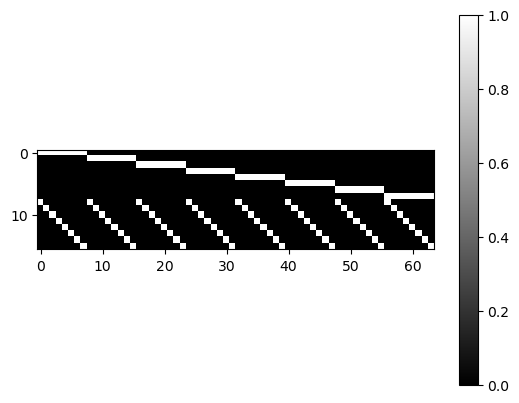

In [27]:
#d)
A, rayos = matriz_proyeccion(8, [(1,0), (0,1)])
plt.imshow(A, cmap='gray')
plt.colorbar()
plt.show()


d) Las filas de A representan los rayos y las columnas representan los píxeles de la imagen. Cada valor de la matriz indica de forma binaria si ese rayo selecciona o no ese píxel: 1 si lo selecciona y 0 si no. La matriz tiene muchos ceros porque cada rayo pasa solamente por algunos píxeles y no por toda la imagen, por lo que la mayoría de los píxeles no son seleccionados por un rayo determinado.

[0.  1.7 3.3 2.3 2.  2.4 1.4 0.  0.  1.7 3.3 2.3 2.  2.4 1.4 0. ]
True


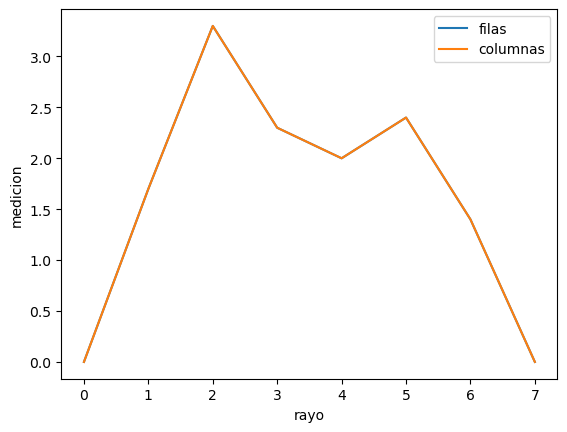

In [51]:
#e) 

A, rayos = matriz_proyeccion(8, [(1,0), (0,1)])
X_fantoma = np.array([
[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0],
[0.0, 0.0, 0.8, 0.3, 0.3, 0.3, 0.0, 0.0],
[0.0, 0.8, 0.8, 0.8, 0.3, 0.3, 0.3, 0.0],
[0.0, 0.3, 0.8, 0.3, 0.3, 0.3, 0.3, 0.0],
[0.0, 0.3, 0.3, 0.3, 0.3, 0.5, 0.3, 0.0],
[0.0, 0.3, 0.3, 0.3, 0.5, 0.5, 0.5, 0.0],
[0.0, 0.0, 0.3, 0.3, 0.3, 0.5, 0.0, 0.0],
[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0],
], dtype=float)

b = A @ x_fantoma

print(b)

print(np.allclose(b[:8], X_fantoma.sum(axis=1)) and np.allclose(b[8:], X_fantoma.sum(axis=0)))
filas_b = b[:8]
columnas_b = b[8:]

plt.plot(filas_b, label= "filas")
plt.plot(columnas_b, label= "columnas")
plt.xlabel("rayo")
plt.ylabel("medicion")
plt.legend()
plt.show()



